In [15]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("student_data.csv")

print(data.shape)
data.head()


(200000, 10)


,Student ID,Student Name,Date of Birth,Field of Study,Year of Admission,Expected Year of Graduation,Current Semester,Specialization,Fees,Discount on Fees
0,165527,Bryan Rogers,2006-01-19,Computer Science,2020,2017,3,Web Development,155152,19572
1,635763,James Hogan,1999-05-23,Mechanical Engineering,2020,2020,2,Machine Learning,157870,14760
2,740021,David Robinson,1997-12-02,Civil Engineering,2017,2022,1,Network Security,55662,5871
3,433076,Susan Miller,1999-10-30,Computer Science,2021,2019,1,Data Science,134955,17284
4,441628,Brittany Martin,1998-01-10,Chemical Engineering,2016,2018,1,Network Security,125934,14871


total admissions per year
Year of Admission
2016    28646
2017    28760
2018    28435
2019    28618
2020    28355
2021    28483
2022    28703
dtype: int64


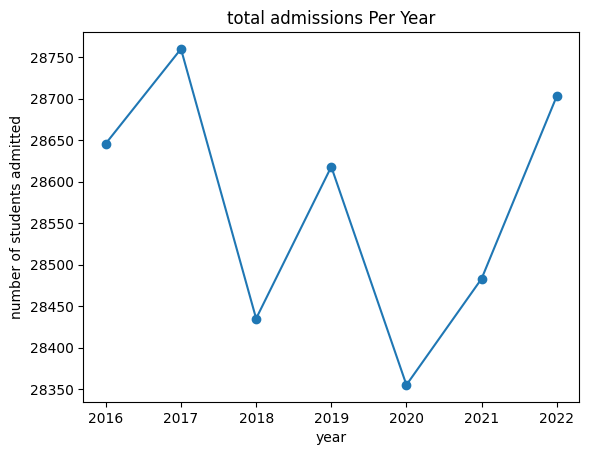

In [16]:
# Long term trend: total admissions per year

adm_year = data.groupby("Year of Admission").size()

print("total admissions per year")
print(adm_year)

# simple line chart, default matplotlib color
plt.plot(adm_year.index, adm_year.values, marker="o")
plt.title("total admissions Per Year")
plt.xlabel("year")
plt.ylabel("number of students admitted")
plt.show()


year growth rate in percent
Year of Admission
2016     NaN
2017    0.40
2018   -1.13
2019    0.64
2020   -0.92
2021    0.45
2022    0.77
dtype: float64


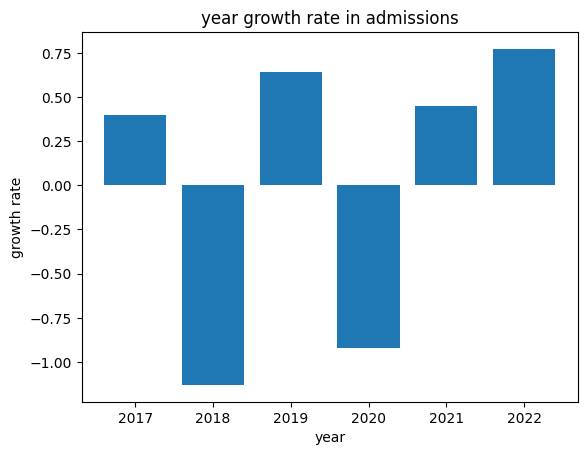

In [17]:
# year over year growth rate in percent

growth_rate = adm_year.pct_change() * 100

print("year growth rate in percent")
print(growth_rate.round(2))


plt.bar(growth_rate.index, growth_rate.values)
plt.title("year growth rate in admissions")
plt.xlabel("year")
plt.ylabel("growth rate")
plt.show()


In [ ]:
# Long term trend admissions per year per field

field_y = data.groupby(["Year of Admission", "Field of Study"]).size().unstack()

print("admissions per year per field")
print(field_y)


admissions per year per field
Field of Study     Chemical Engineering  Civil Engineering  Computer Science  \
Year of Admission                                                              
2016                               5728               5755              5763   
2017                               5769               5790              5666   
2018                               5679               5612              5684   
2019                               5781               5595              5667   
2020                               5692               5574              5705   
2021                               5689               5687              5664   
2022                               5682               5761              5811   

Field of Study     Electrical Engineering  Mechanical Engineering  
Year of Admission                                                  
2016                                 5745                    5655  
2017                                 5843    

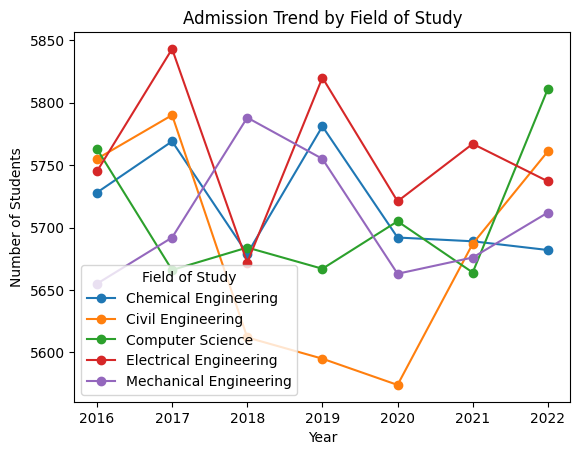

In [19]:
# simple line chart, one line per field, default colors
field_y.plot(marker="o")
plt.title("Admission Trend by Field of Study")
plt.xlabel("Year")
plt.ylabel("Number of Students")
plt.show()


In [20]:
# Admission probability by field
# converts counts into a yearly percent share
# a rising share means that field is taking a bigger part of admissions

field_share_percent = field_y.div(field_y.sum(axis=1), axis=0) * 100

print("Share of admissions per field, in percent")
print(field_share_percent.round(2))


Share of admissions per field, in percent
Field of Study     Chemical Engineering  Civil Engineering  Computer Science  \
Year of Admission                                                              
2016                              20.00              20.09             20.12   
2017                              20.06              20.13             19.70   
2018                              19.97              19.74             19.99   
2019                              20.20              19.55             19.80   
2020                              20.07              19.66             20.12   
2021                              19.97              19.97             19.89   
2022                              19.80              20.07             20.25   

Field of Study     Electrical Engineering  Mechanical Engineering  
Year of Admission                                                  
2016                                20.06                   19.74  
2017                             

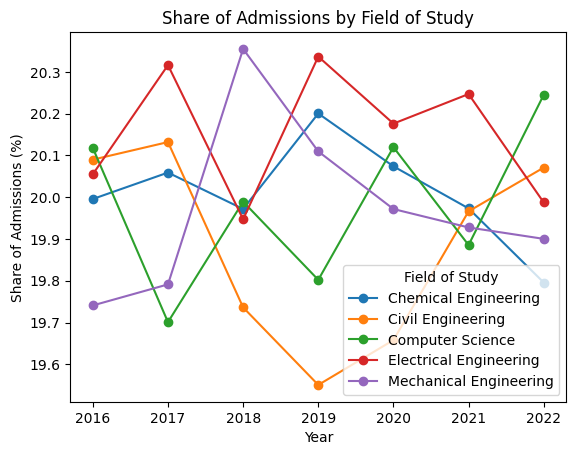

In [21]:
# simple line chart of share percent, default colors
field_share_percent.plot(marker="o")
plt.title("Share of Admissions by Field of Study")
plt.xlabel("Year")
plt.ylabel("Share of Admissions (%)")
plt.show()


In [22]:
# Long term change in fees and discounts
# cost can affect who applies, so check if fees or discounts are trending

fees_trend = data.groupby("Year of Admission")[["Fees", "Discount on Fees"]].mean()

print("Average fees and discount per year")
print(fees_trend.round(0))


Average fees and discount per year
                       Fees  Discount on Fees
Year of Admission                            
2016               124993.0           12435.0
2017               125267.0           12488.0
2018               124680.0           12402.0
2019               125067.0           12506.0
2020               125328.0           12544.0
2021               125294.0           12553.0
2022               125021.0           12462.0


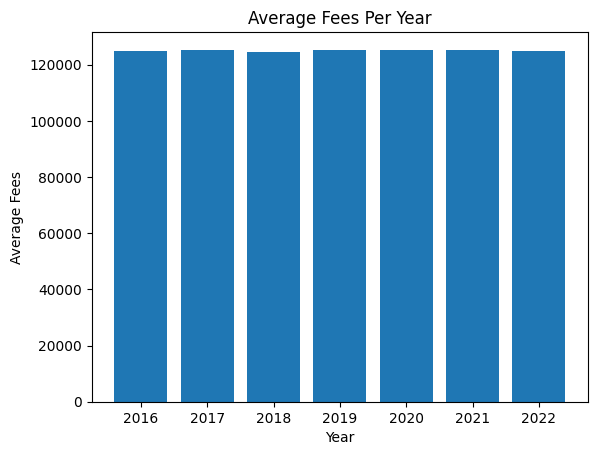

In [23]:

plt.bar(fees_trend.index, fees_trend["Fees"])
plt.title("Average Fees Per Year")
plt.xlabel("Year")
plt.ylabel("Average Fees")
plt.show()


Average age at admission per year
Year of Admission
2016    14.60
2017    15.60
2018    16.57
2019    17.58
2020    18.57
2021    19.57
2022    20.59
Name: Age at Admission, dtype: float64


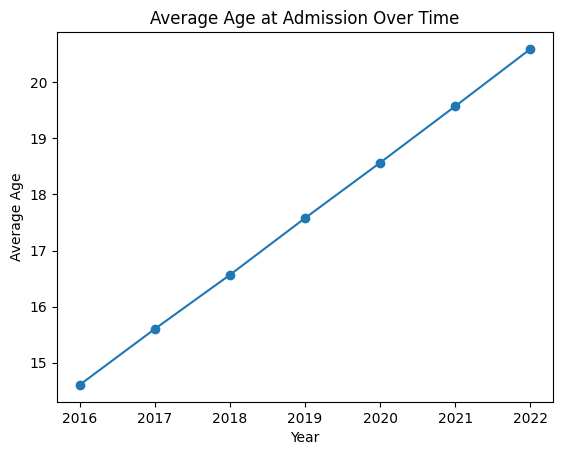

In [24]:
# Long term demographic change: age at admission
# uses date of birth and year of admission to estimate age when admitted

data["Birth Year"] = pd.to_datetime(data["Date of Birth"]).dt.year
data["Age at Admission"] = data["Year of Admission"] - data["Birth Year"]

age_trend = data.groupby("Year of Admission")["Age at Admission"].mean()

print("Average age at admission per year")
print(age_trend.round(2))

# simple line chart, default color
plt.plot(age_trend.index, age_trend.values, marker="o")
plt.title("Average Age at Admission Over Time")
plt.xlabel("Year")
plt.ylabel("Average Age")
plt.show()
